# Модель для предсказания вероятности клика на рекламный банер

## План работы
- Построить модель бинарной классификации, которая предсказывает вероятность клика — показатель CTR — на рекламное объявление.
- Поле которое является целевой переменной `click`.
- Оценка модели по трем ключевым метрикам: PR-AUC, Log Loss и оценка Бриера.

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовка библиотек
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

In [1]:
from unicodedata import category
!pip install phik -U -q
!pip install scikit-learn -U -q

In [182]:
#Импорт библиотек
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import phik
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, average_precision_score
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.feature_selection import VarianceThreshold


#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

In [3]:
RANDOM_STATE = 42
N_FOLDS = 5

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [4]:
# Загрузка данных
df = pd.read_csv("datasets/ds_s16_ad_click_dataset.csv", sep=',', decimal='.')
df_len = len(df)

In [5]:
# Информация о датасете
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

In [9]:
# Выводим первые строки первой половины столбцов датафрейма на экран
df.iloc[:, :len(df.columns)//2].head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702


In [10]:
# Выводим первые строки второй половины столбцов датафрейма на экран
df.iloc[:, len(df.columns)//2:].head()

,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [8]:
#Выведем статистику по датасету
df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,0.172060,1.410256e+07,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,...,53173.383240,83.685180,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,0.377436,2.967892e+02,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,...,49960.181871,70.539513,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,...,-1.000000,13.000000,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,...,-1.000000,23.000000,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,...,100049.000000,61.000000,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,...,100094.000000,108.000000,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,...,100248.000000,255.000000,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300



Названия столбцов уже приведены к единому виду snake_case.

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

## 2. Исследовательский анализ данных (EDA)


#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.


Датасет ds_s16_ad_click_dataset содержит 33 столбца и 50000 строк, в которых представлена информация о рекламных объявлениях.

В датасете представлено 10 категориальных признаков:
site_id, site_domain, site_category, app_id, app_domain, app_category, device_id, device_ip, device_model, ml_feature_7.
и 23 числовых признака: все остальные.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.


click - был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.
Столбец click содержит целые числа и хранится в типе данных int64, размерность этих данных можно оптимизировать.
Пропусков в данном столбце в датасете нет.

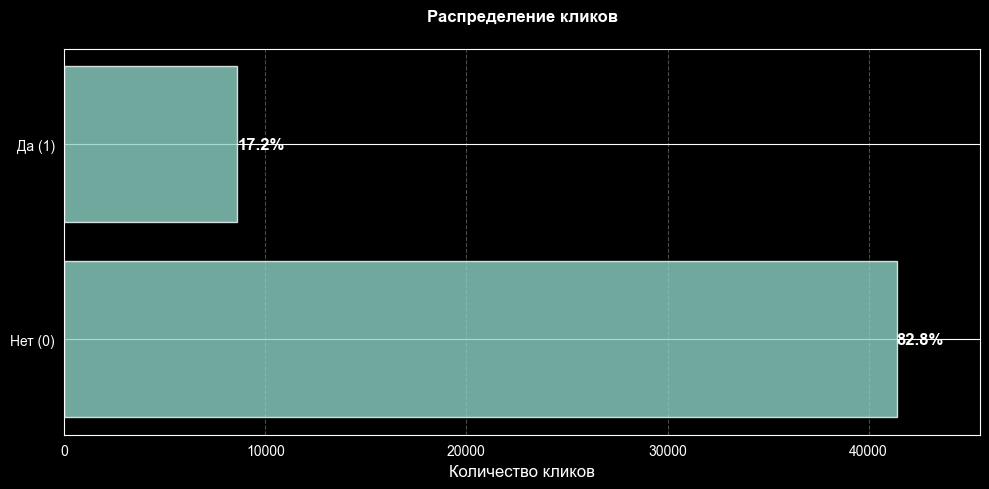

In [11]:
# Распределение оттока клиентов
plt.figure(figsize=(10, 5))

counts = df['click'].value_counts()
bars = plt.barh(['Нет (0)', 'Да (1)'], counts.values, alpha=0.8)

for bar, count in zip(bars, counts.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2.,
        f'{count/len(df)*100:.1f}%',
        ha='left', va='center', fontsize=12, fontweight='bold'
    )

plt.title('Распределение кликов', fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Количество кликов', fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.xlim(0, max(counts.values) * 1.1)
plt.tight_layout()
plt.show()

В распределении явный дисбаланс классов, 17.2% клик был и 82.8% клика не было, исходя из явного дисбаланска классов для поиска оптимальной модели лучше опираться на метрику PR-AUC.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.


Для обучения модели точно не понадобится признак id записи показа баннера так как он уникален и является идентификатором события(строки), этот признак можно сразу удалить.
device_id и device_ip малоинформативные признаки для базовой модели, id просто идентификатор, а ip сам по себе ничего не дает если не сделать из него новую фичу.

In [168]:
#Удаляем столбец
df = df.drop(columns=['id', 'device_id', 'device_ip'])

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

In [16]:
# Сколько строк имеют хотя бы один пропуск
rows_with_nan = df.isna().any(axis=1).sum()
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_nan} из {len(df)} "
      f"({rows_with_nan/len(df)*100:.2f}%)")


Строк с хотя бы одним пропуском: 0 из 50000 (0.00%)


Так как данные без пропусков, заплонять их не нужно.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.


In [17]:
cat_features = [
    'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_7'
]

In [18]:
#Количество уникальных значений в столбцах
df[cat_features].nunique().sort_values()

ml_feature_7         3
site_category       18
app_category        22
app_domain          67
app_id             976
site_domain       1013
site_id           1160
device_model      2521
device_id         8580
device_ip        41455
dtype: int64

ml_feature_7 лучше закодировать при помощи One-Hot Encoding, так как у этого признака небольшое число уникальных значений.
Остальные признаки лучше кодировать Target Encoding, так как при кодировании One Hot приведет увеличению количества параметров в тысячи раз.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.


In [106]:
def plot_distribution(tmp_df, bin_col, second_col, title, x_label, y_label='Плотность', figsize=(16, 6), fontsize=12, bins=40):
    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [2, 1]})
    click0 = tmp_df[tmp_df[bin_col]==0][second_col]
    click1 = tmp_df[tmp_df[bin_col]==1][second_col]

    ax1 = axes[0]
    ax1.hist(click0, bins=bins, alpha=0.5, label='Нет (0)', color='lightcoral', edgecolor='black', density=True)
    ax1.hist(click1, bins=bins, alpha=0.5, label='Да (1)', color='lightblue', edgecolor='black', density=True)

    ax1.axvline(click0.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Среднее (0): {click0.mean():.2f}')
    ax1.axvline(click1.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Среднее (1): {click1.mean():.2f}')
    ax1.axvline(click0.median(), color='red', linestyle=':', linewidth=2, label=f'Медиана (0): {click0.median():.2f}')
    ax1.axvline(click1.median(), color='blue', linestyle=':', linewidth=2, label=f'Медиана (1): {click1.median():.2f}')

    ax1.set_title(title, fontsize=fontsize, fontweight='bold')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel(y_label)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    data_to_plot = [click0, click1]
    box = ax2.boxplot(data_to_plot, vert=True, patch_artist=True, tick_labels=['Нет (0)', 'Да (1)'])

    colors = ['lightcoral', 'lightblue']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax2.set_xlabel('Совершен клик')
    ax2.set_title('Ящик с усами', fontsize=fontsize, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

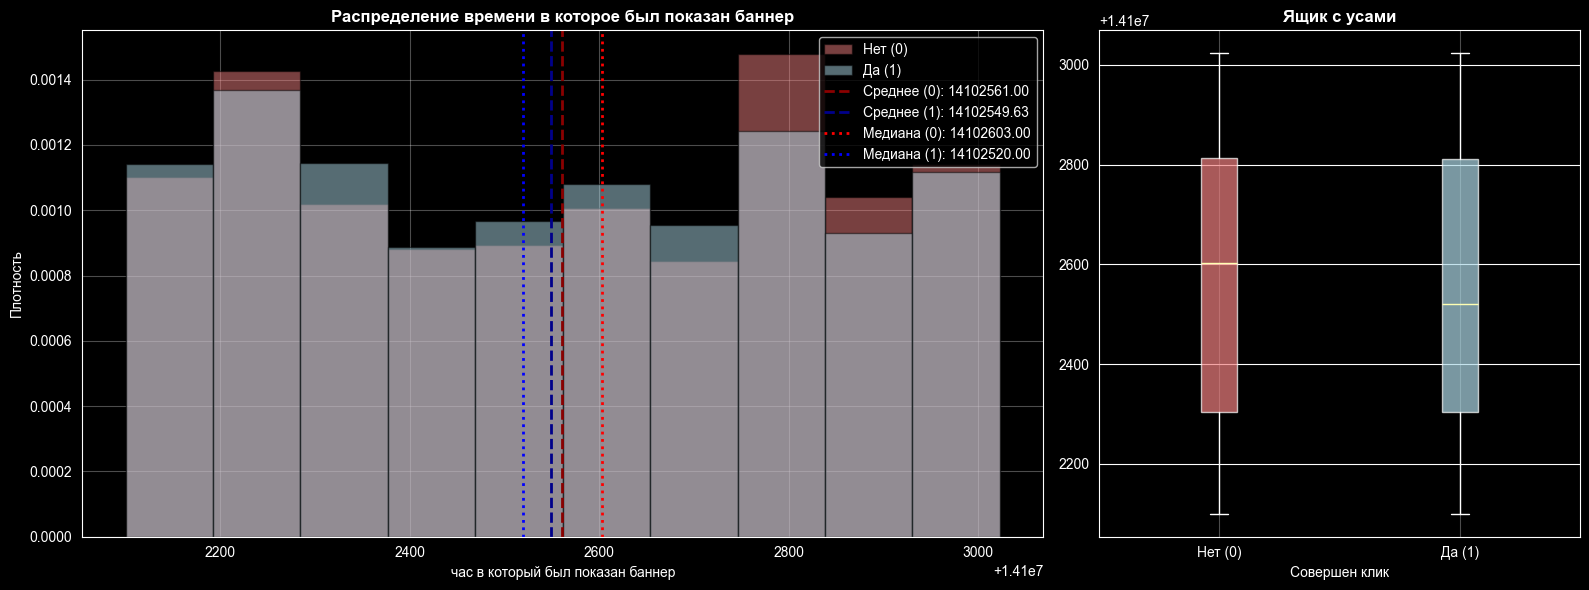

In [107]:
plot_distribution(df, 'click', 'hour',
            'Распределение времени в которое был показан баннер', 'час в который был показан баннер', bins=10)

Распределение по дням нормальное. Судя по распределению все данные приведены за октябрь 2014 года с 21 по 30 числа, все в 00 часов, похоже на ошибку/неточноть/агрегацию в данных. Выбросов в данных нет.

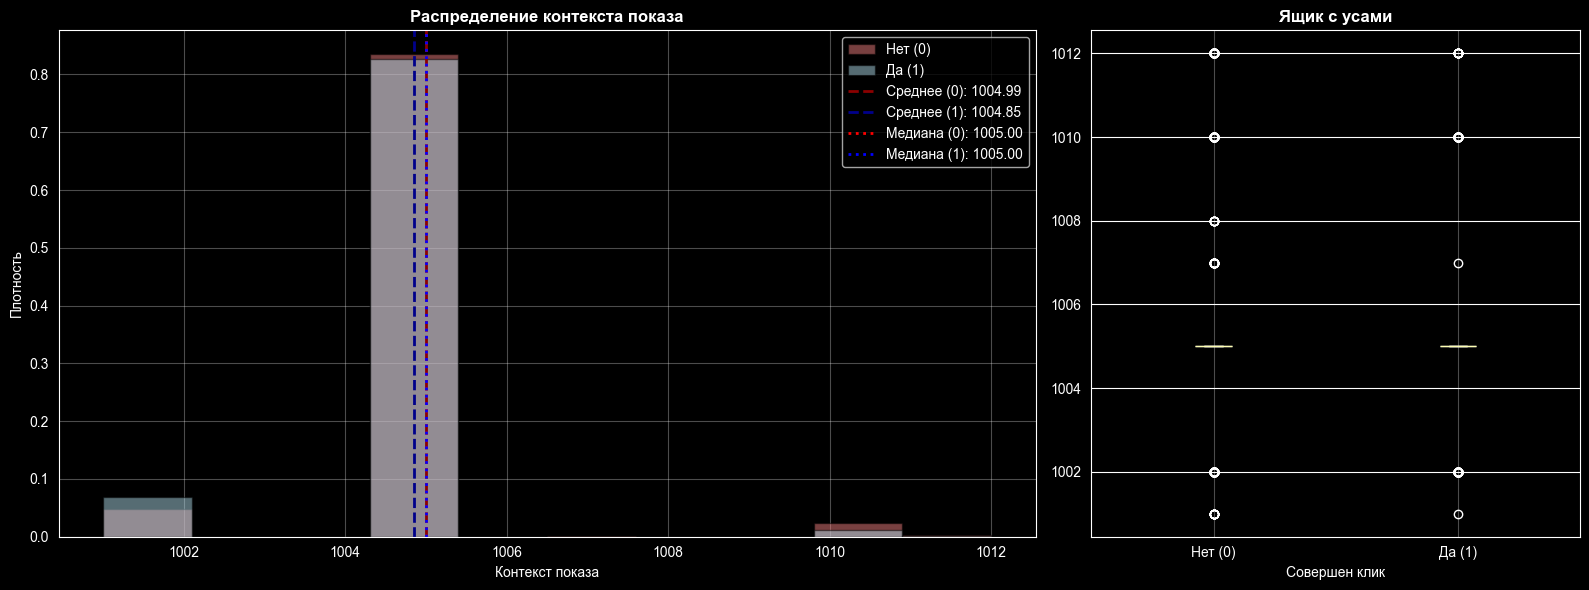

In [108]:
plot_distribution(df, bin_col='click', second_col='C1',
            title='Распределение контекста показа', x_label='Контекст показа', bins=10)

Бользая часть значений признака C1 сконцентрирована на отметке 1005, остальные значения их фоне выглядят выбросами.

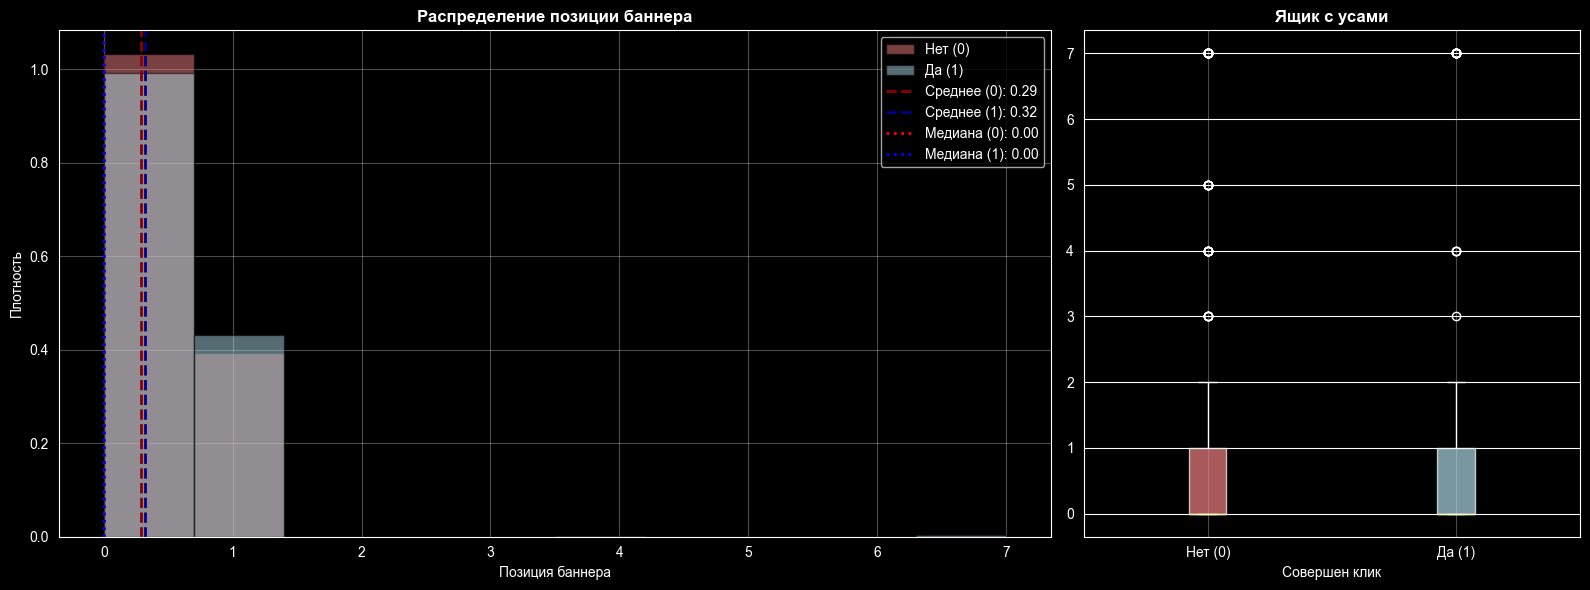

In [109]:
plot_distribution(df, 'click', 'banner_pos',
            'Распределение позиции баннера', 'Позиция баннера', bins=10)

Большая часть измерений сконцентрирована в позициях 0 и 1.

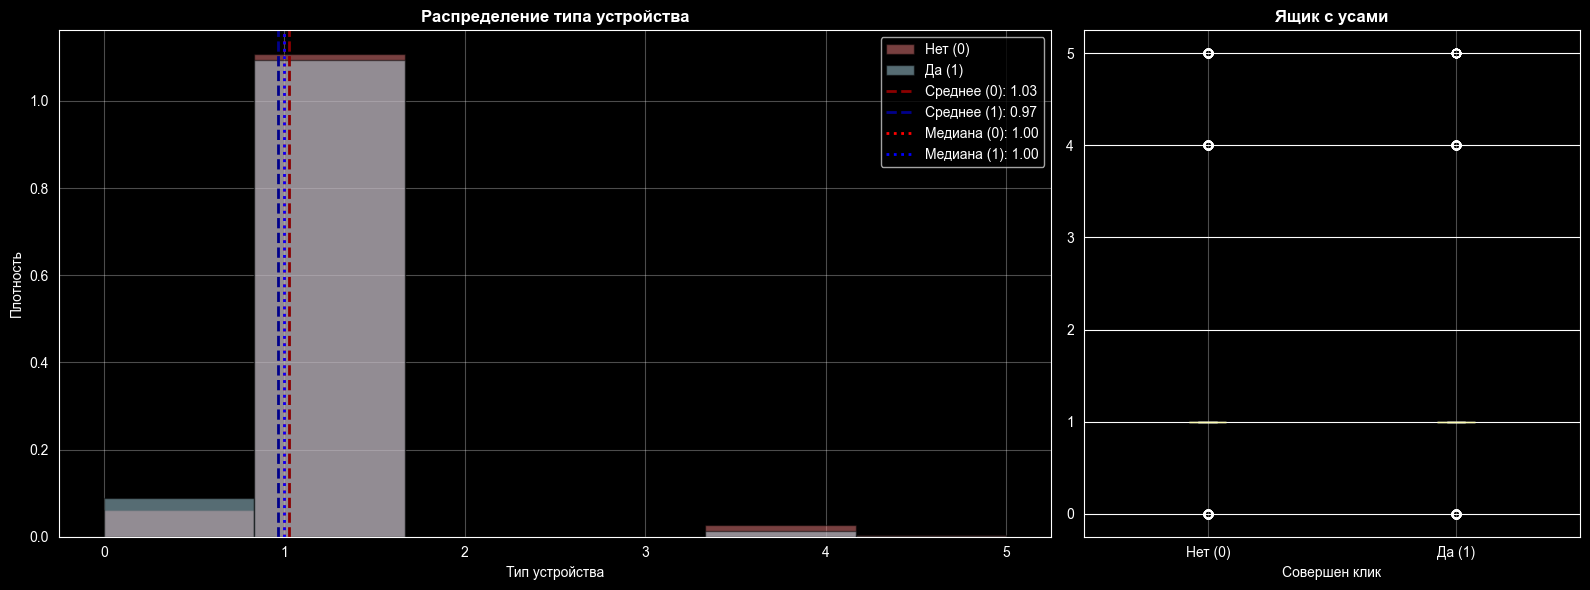

In [110]:
plot_distribution(df, 'click', 'device_type',
            'Распределение типа устройства', 'Тип устройства', bins=6)

Большая часть устройств имеет тип 1.

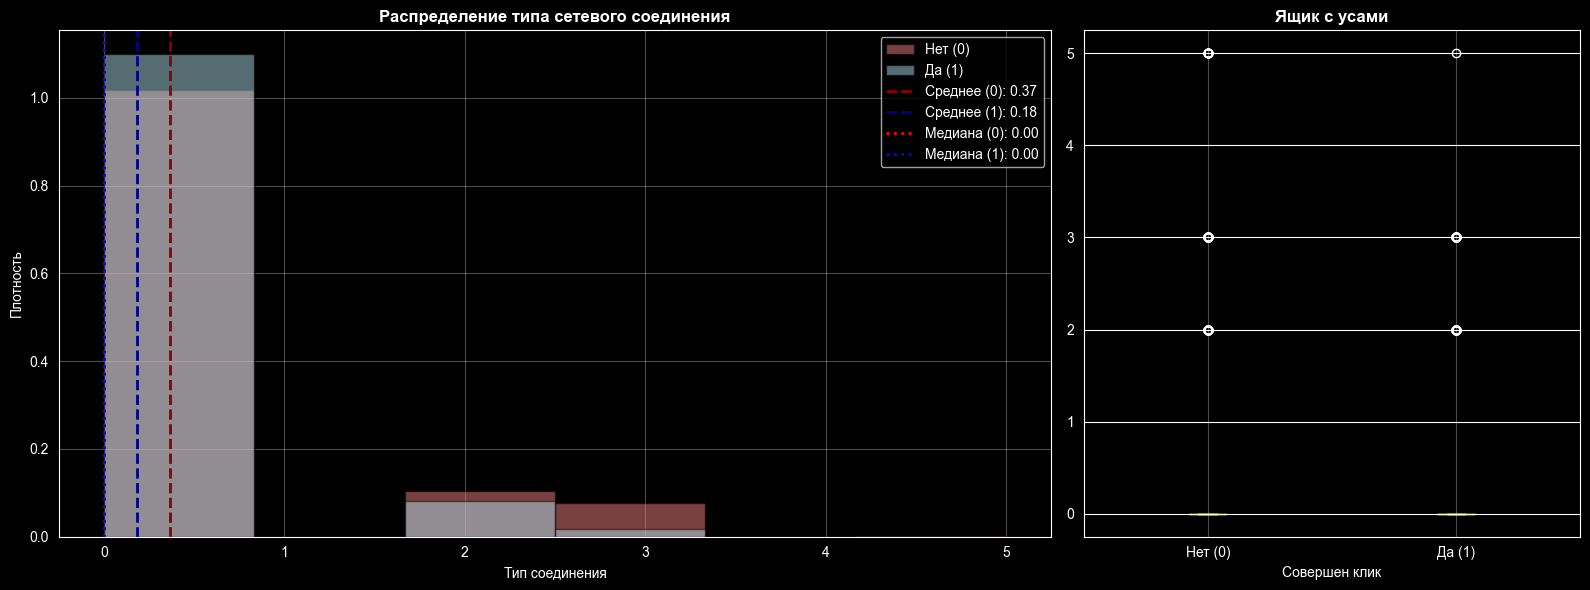

In [111]:
plot_distribution(df, 'click', 'device_conn_type',
            'Распределение типа сетевого соединения', 'Тип соединения', bins=6)

Распределение с хвостом в право. Большая часть типов сетевого соединения - 0.

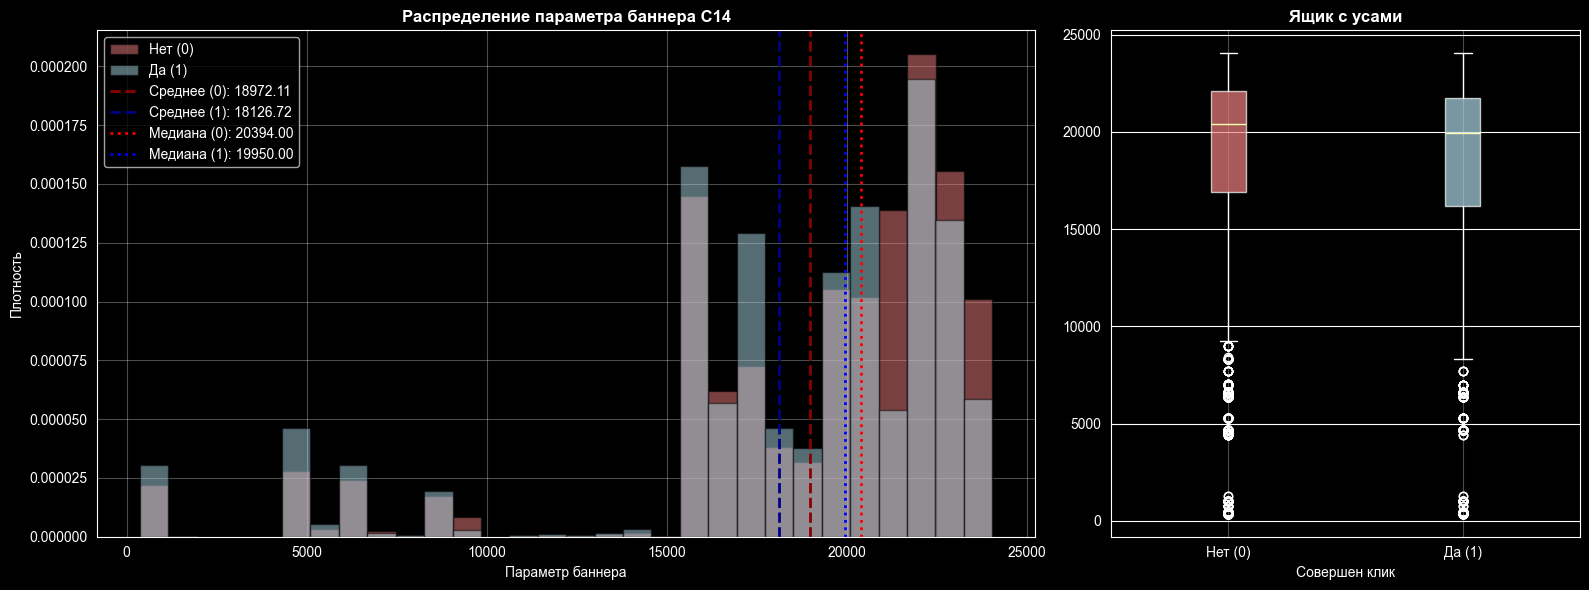

In [116]:
plot_distribution(df, 'click', 'C14',
            'Распределение параметра баннера C14', 'Параметр баннера', bins=30)

Распределение с левым хвостом. Большая часть сзачений в диапазоне 16000 - 21000, с выбросами ниже 4000.

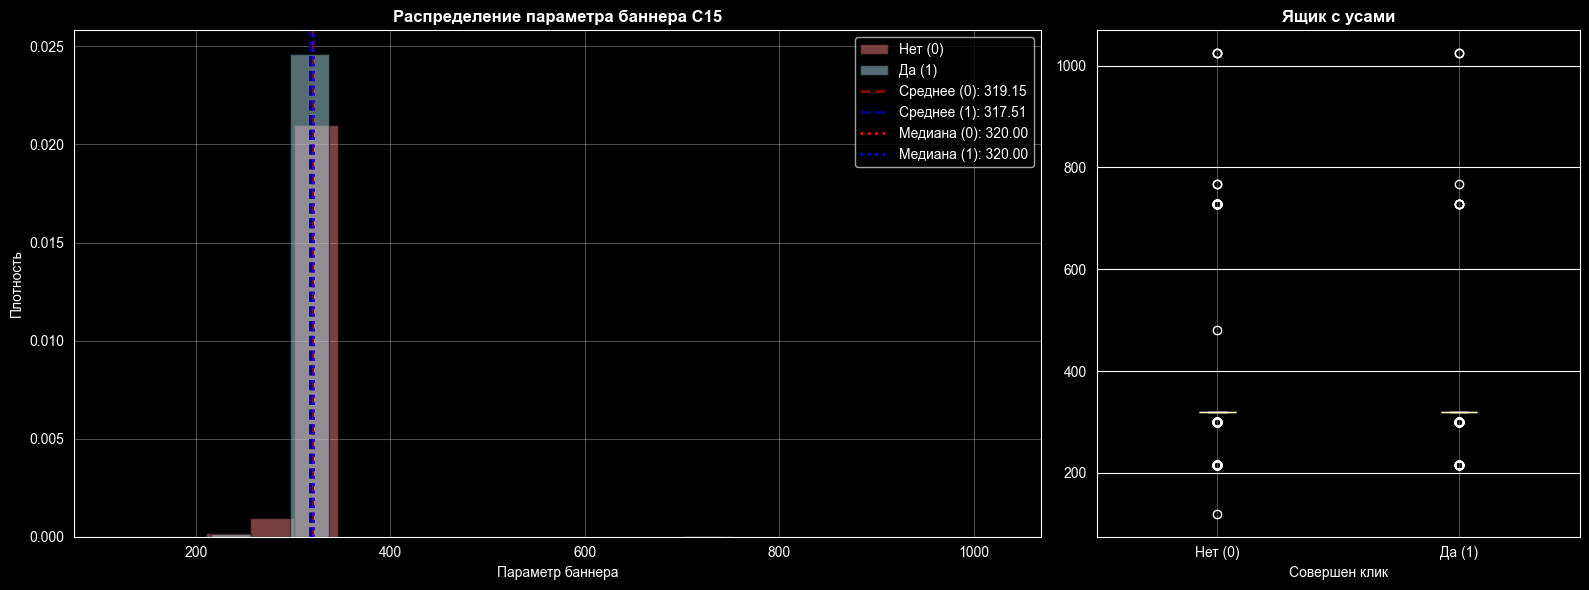

In [126]:
plot_distribution(df, 'click', 'C15',
            'Распределение параметра баннера C15', 'Параметр баннера', bins=20)

Правтически все значения параметра C15 сконцентрированы в области 300, с выбросами ниже 200 и от 400 до 1000 и выше.

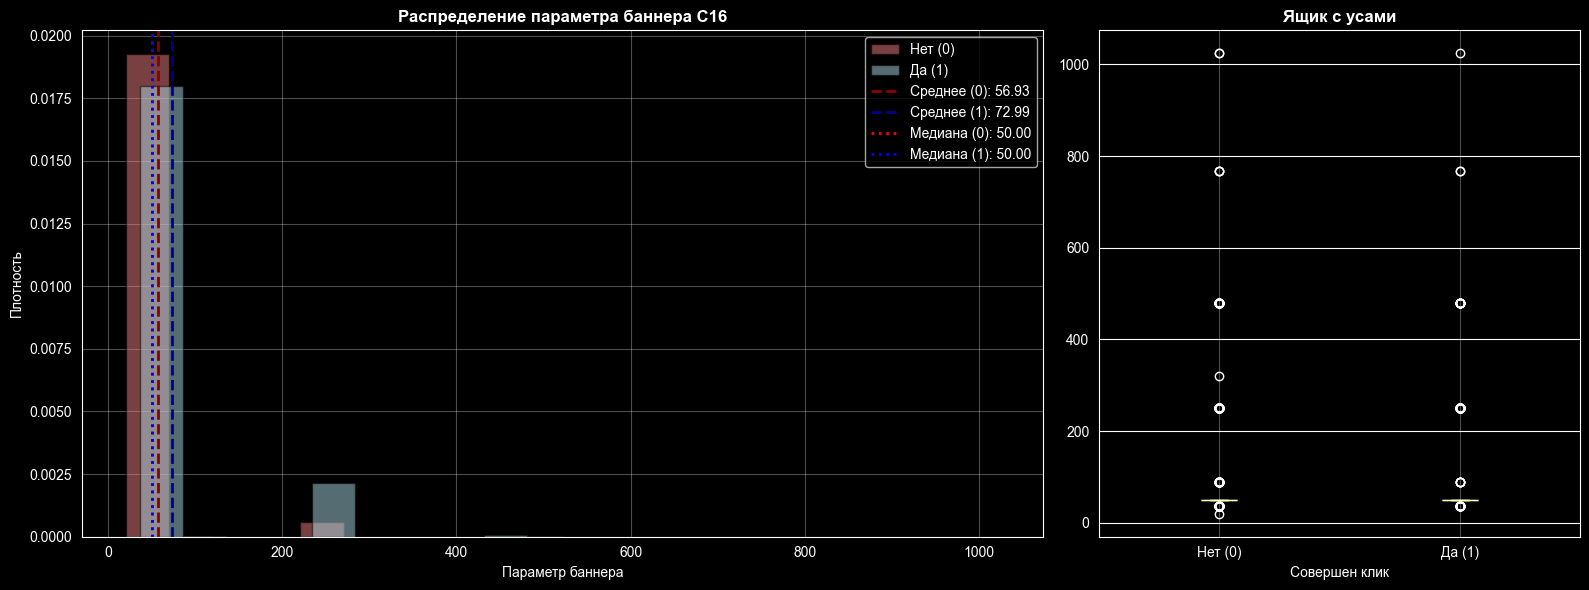

In [125]:
plot_distribution(df, 'click', 'C16',
            'Распределение параметра баннера C16', 'Параметр баннера', bins=20)

Правтически все значения параметра C16 сконцентрированы в области 50, с выбросами от 200 до 1000 и выше.

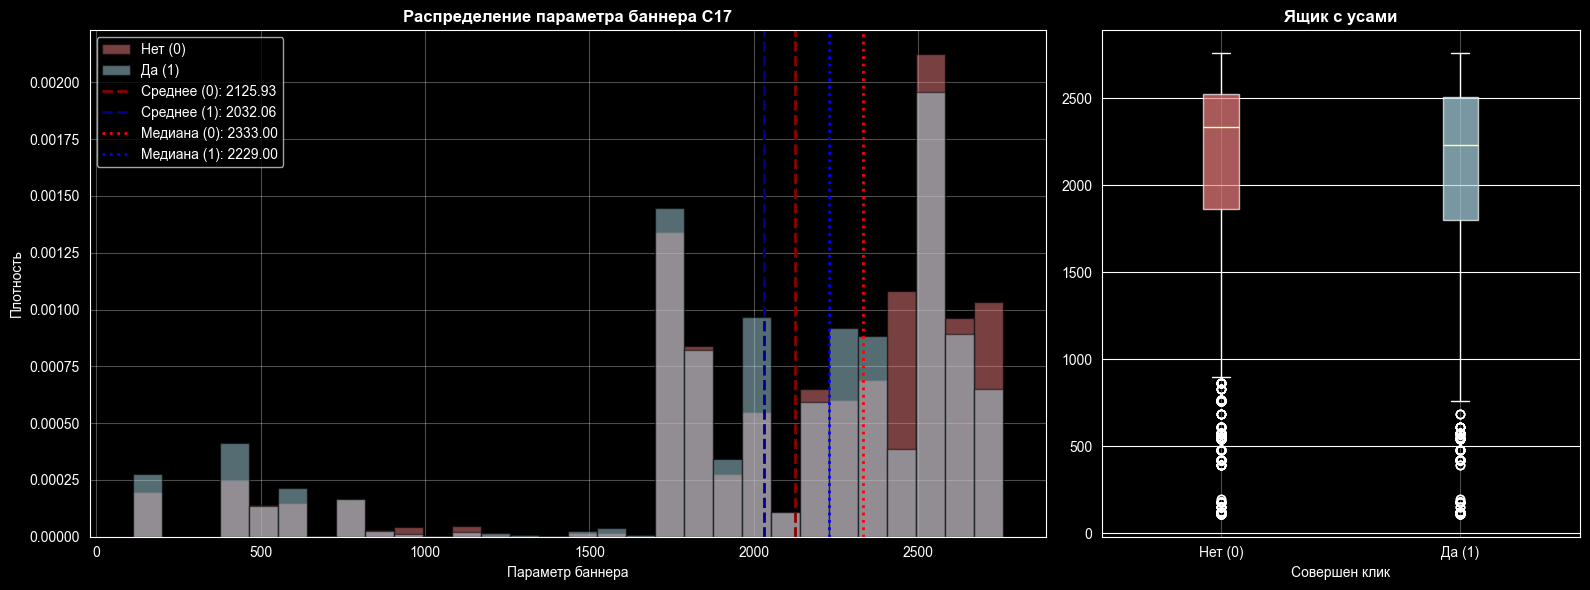

In [128]:
plot_distribution(df, 'click', 'C17',
            'Распределение параметра баннера C17', 'Параметр баннера', bins=30)

Распределение с левым хвостом,  большая часть значений сс диапазоне от 1700 до 2700.

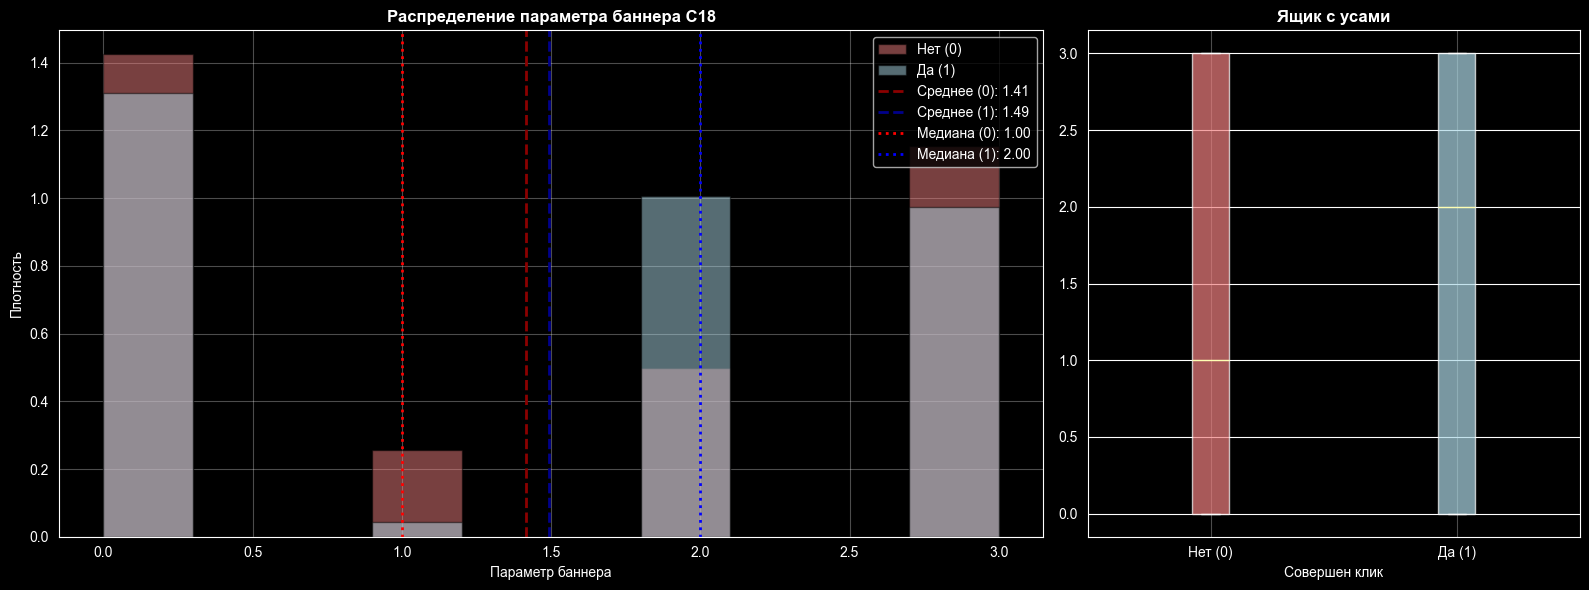

In [131]:
plot_distribution(df, 'click', 'C18',
            'Распределение параметра баннера C18', 'Параметр баннера', bins=10)

Распределение близко к бимодальному с пиками по краям. Большинство измерений находятся на отметках 0 и 3.

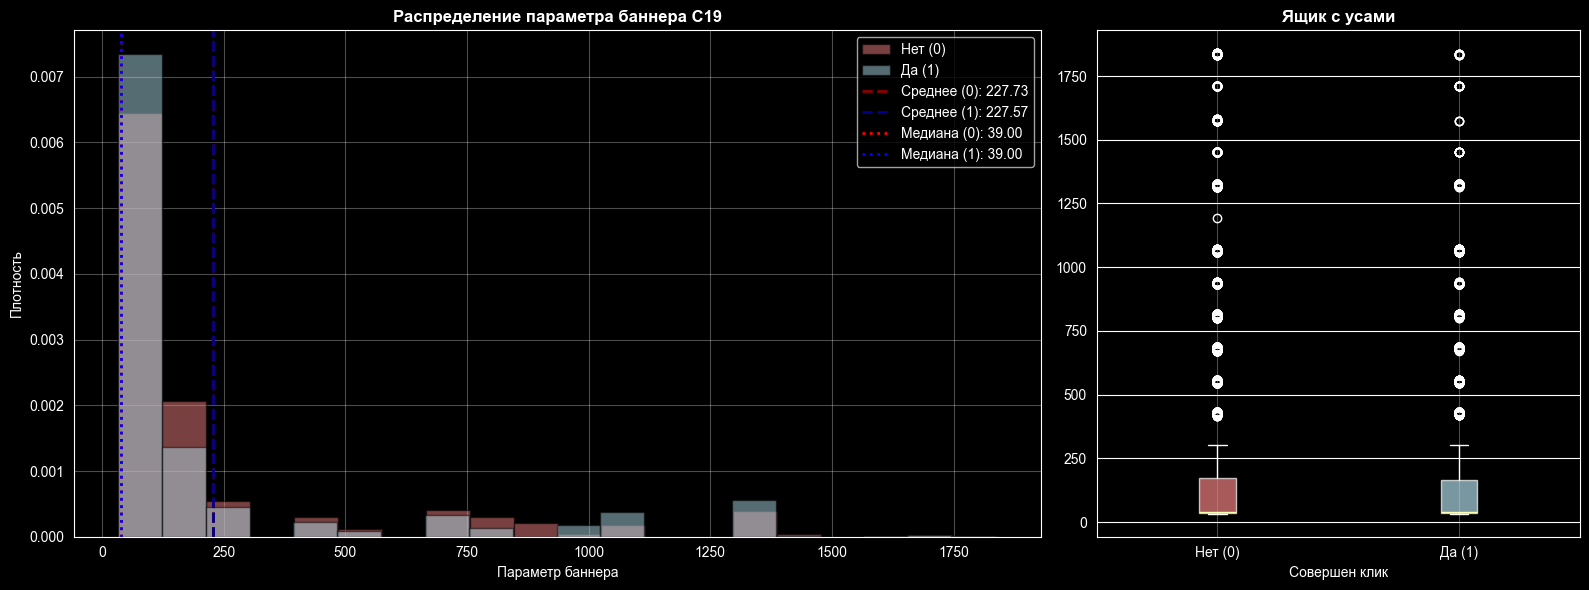

In [134]:
plot_distribution(df, 'click', 'C19',
            'Распределение параметра баннера C19', 'Параметр баннера', bins=20)

Распределение с длинным хвостом в право, большая частьизмерений от 0 до 100.

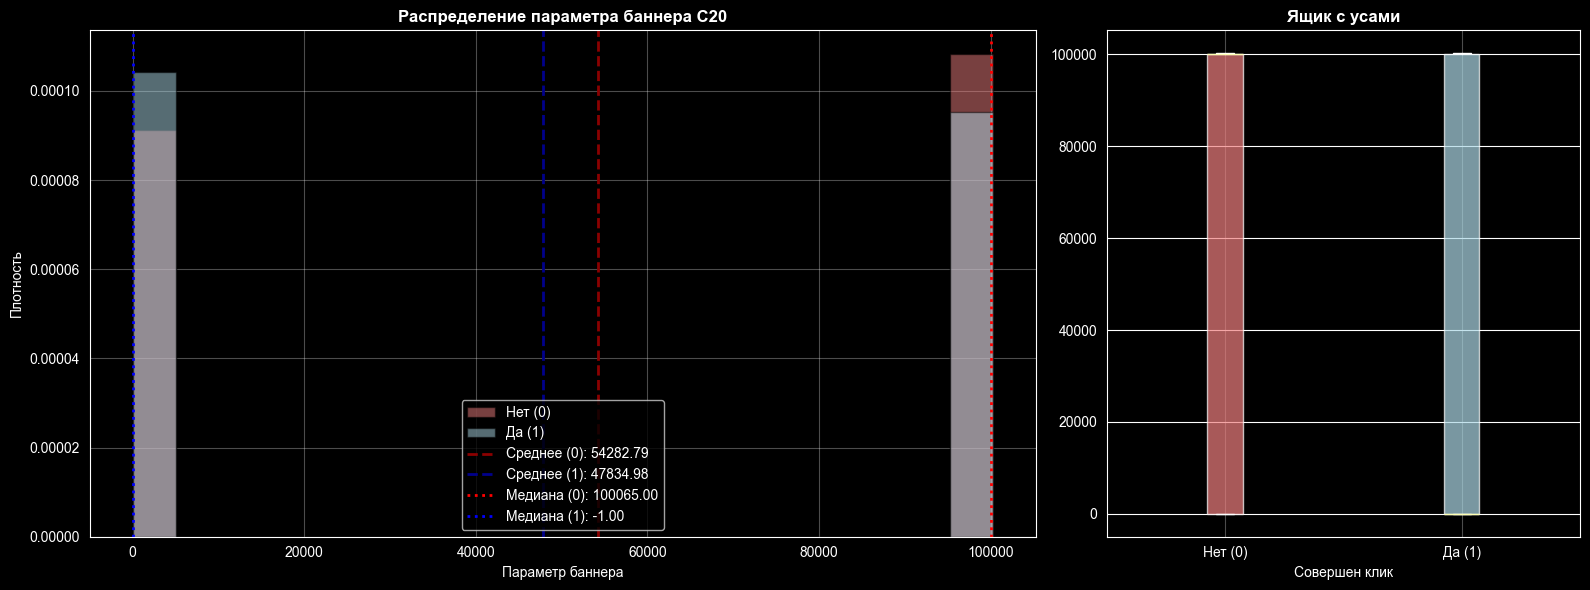

In [138]:
plot_distribution(df, 'click', 'C20',
            'Распределение параметра баннера C20', 'Параметр баннера', bins=20)

На распределении два пикав области 0 и 100000. Судя по распределению, признак похоже бинарный.

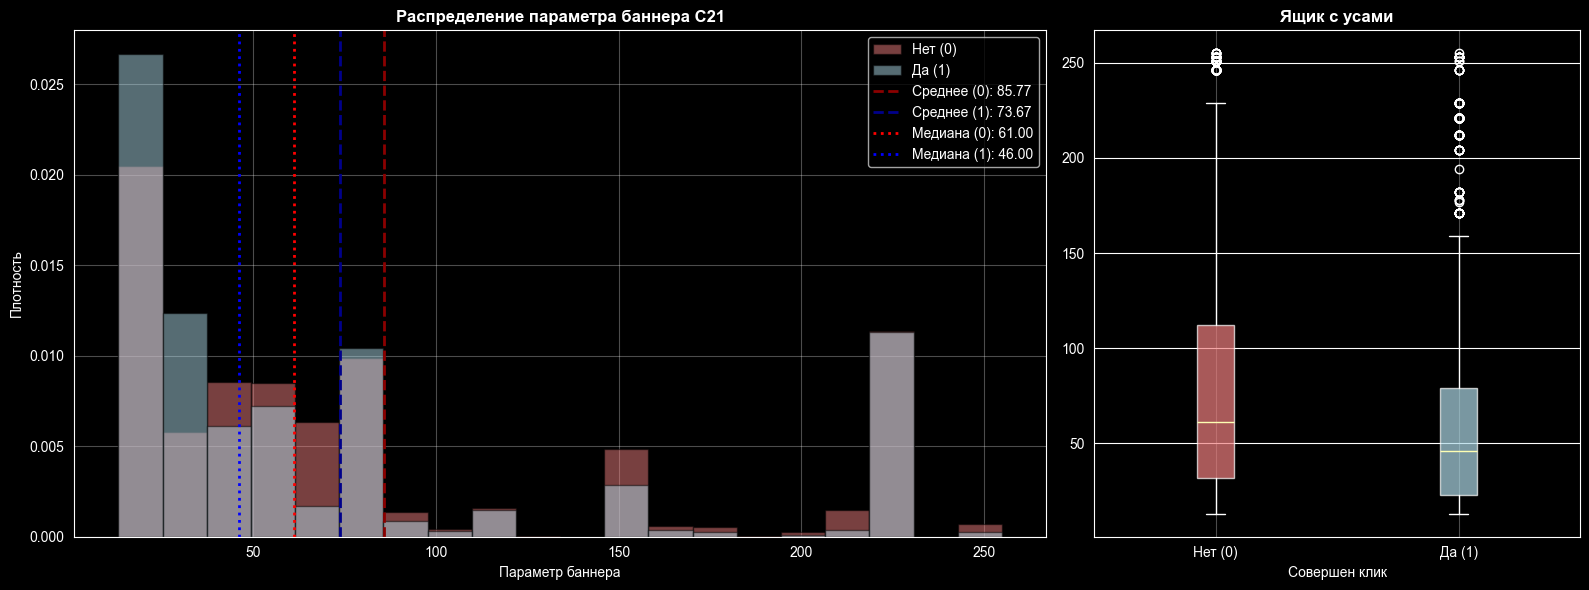

In [141]:
plot_distribution(df, 'click', 'C21',
            'Распределение параметра баннера C21', 'Параметр баннера', bins=20)

Распределение с хвостом в право, большая часть значений в области от 0 до 80.

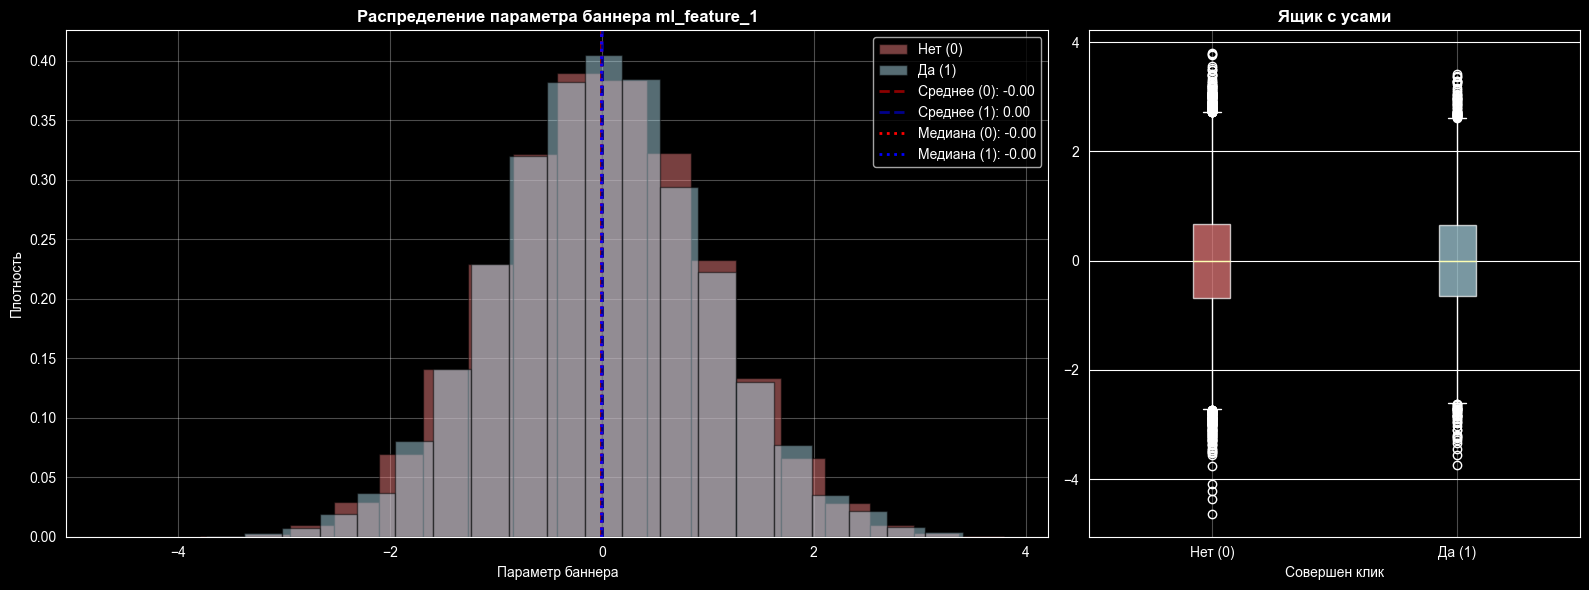

In [142]:
plot_distribution(df, 'click', 'ml_feature_1',
            'Распределение параметра ml_feature_1', 'Параметр баннера', bins=20)

Симметричное распределение с пиком в области 0.

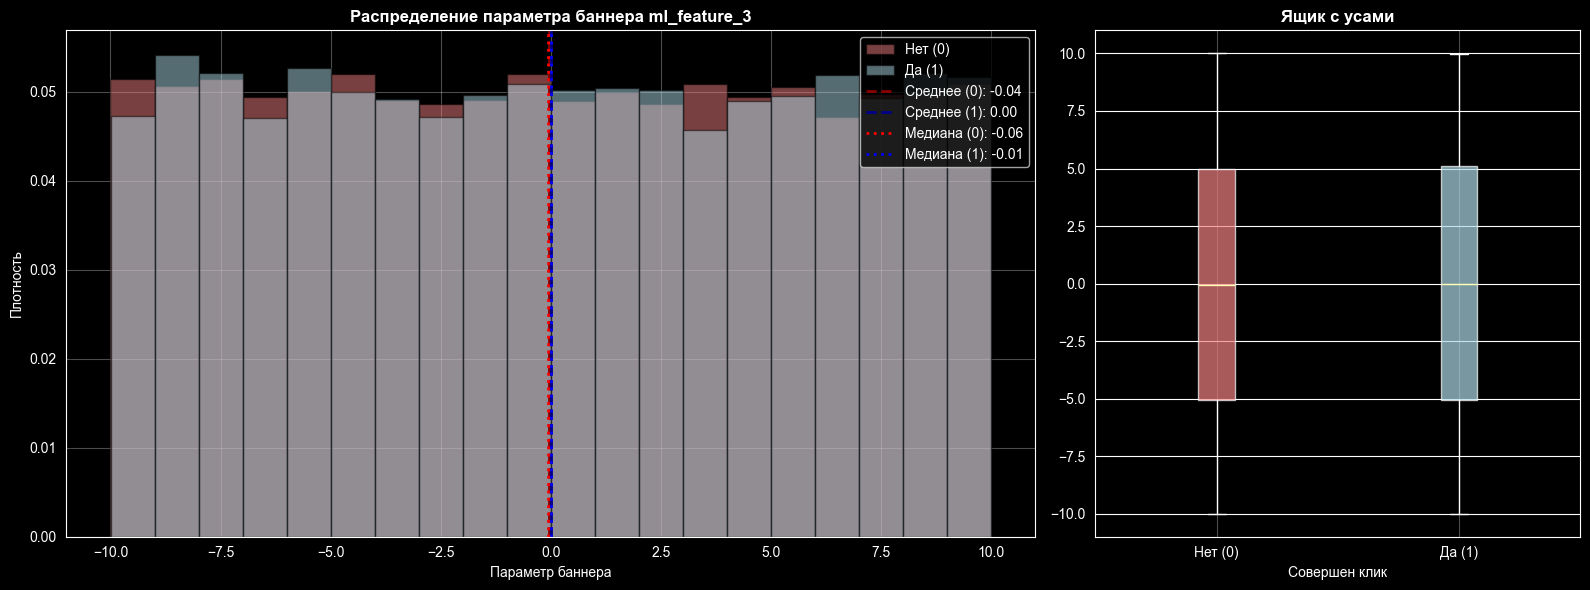

In [143]:
plot_distribution(df, 'click', 'ml_feature_3',
            'Распределение параметра ml_feature_3', 'Параметр баннера', bins=20)

Равномерное распределение от -10 до 10.

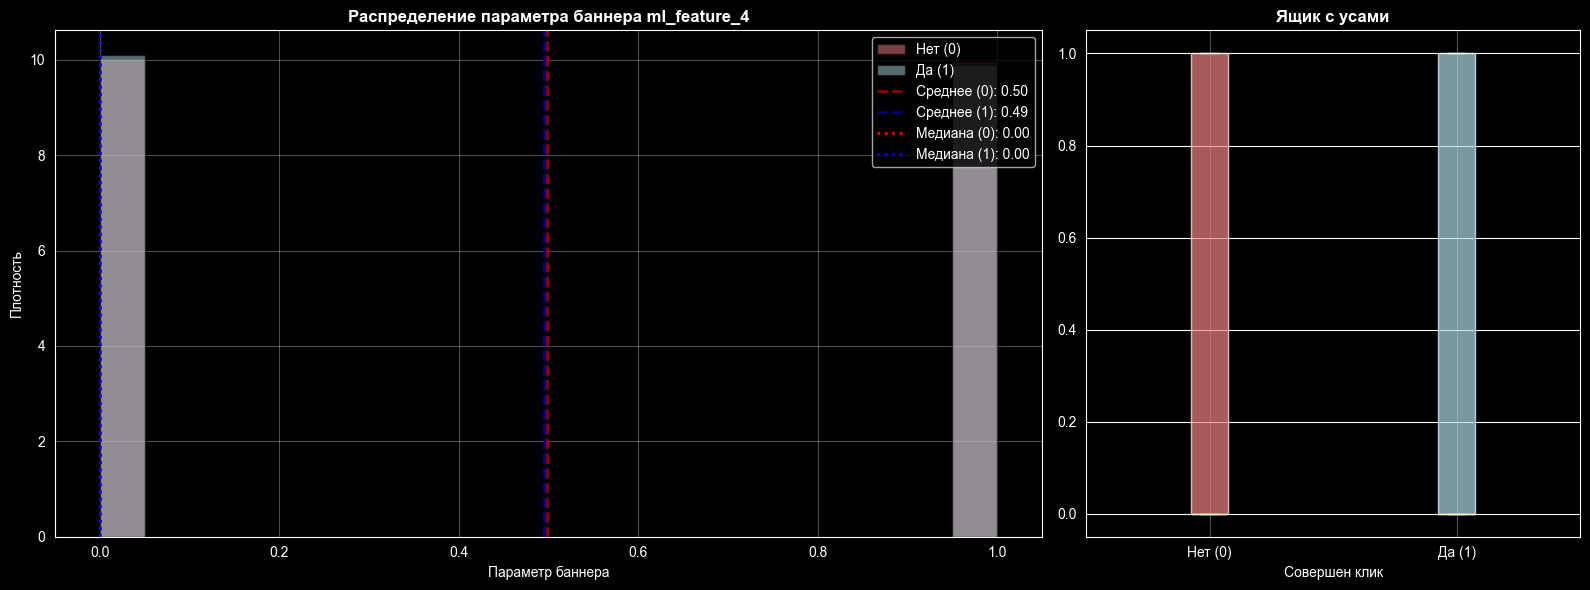

In [146]:
plot_distribution(df, 'click', 'ml_feature_4',
            'Распределение параметра ml_feature_4', 'Параметр баннера', bins=20)

Бинарный признак ml_feature_4, равномерно распределен между классами click0 и click1.

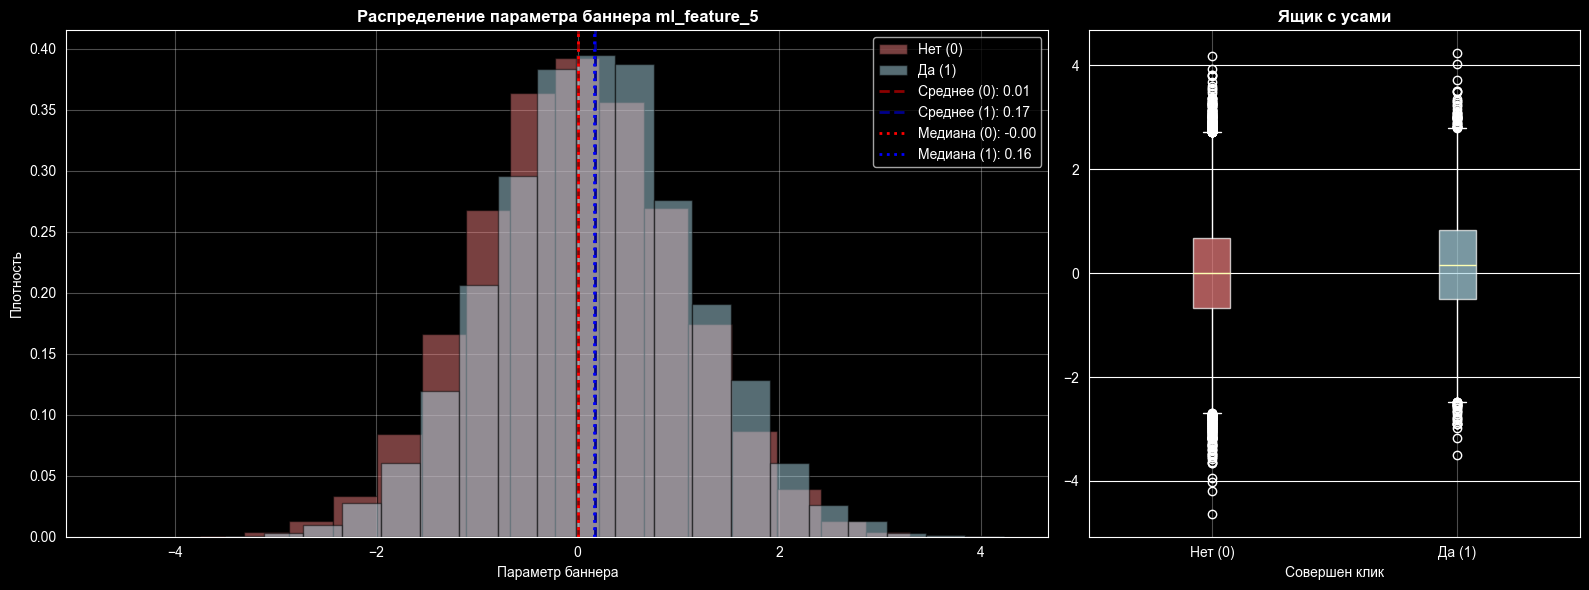

In [147]:
plot_distribution(df, 'click', 'ml_feature_5',
            'Распределение параметра ml_feature_5', 'Параметр баннера', bins=20)

Симметричное распределение для двух классов, но класс Да смещен относительно 0 вправо.


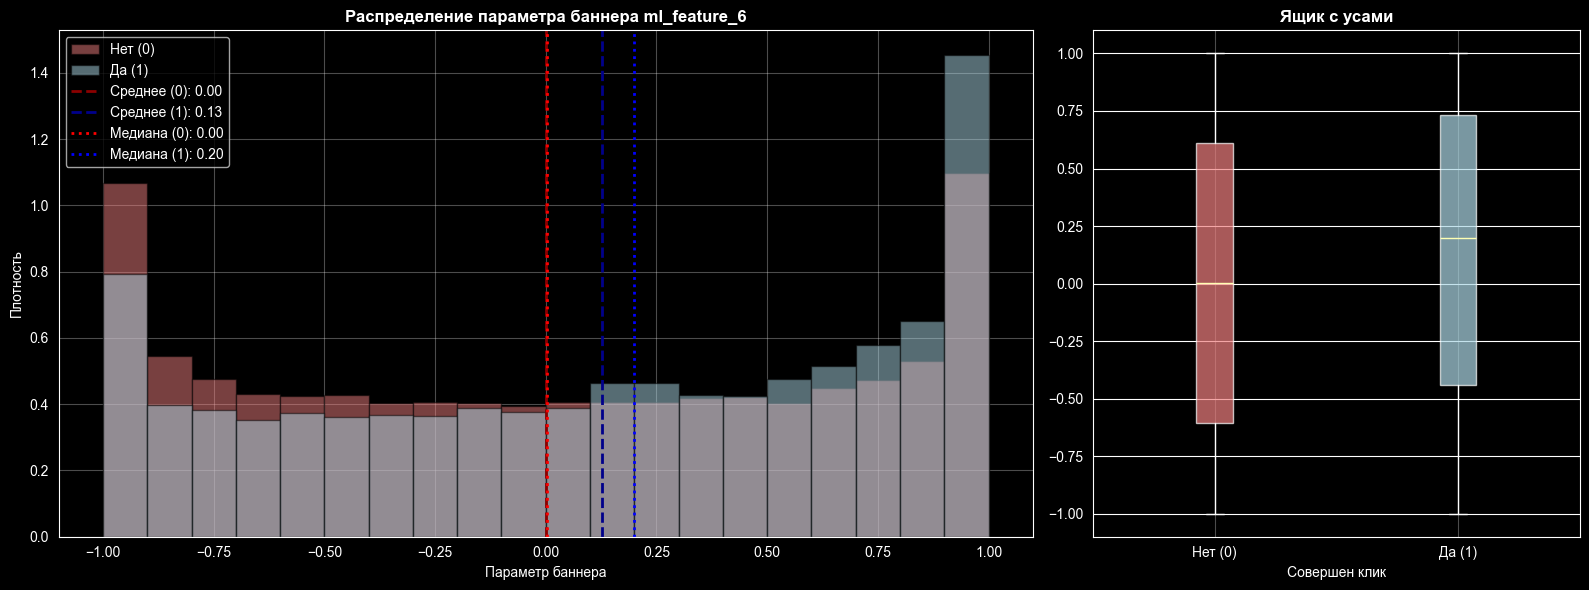

In [148]:
plot_distribution(df, 'click', 'ml_feature_6',
            'Распределение параметра ml_feature_6', 'Параметр баннера', bins=20)

U-образное распределение, пики в областях -1 и 1. Плотность класса `Нет` больше в отрицательной области, а плотность класса `Да` в положительной.

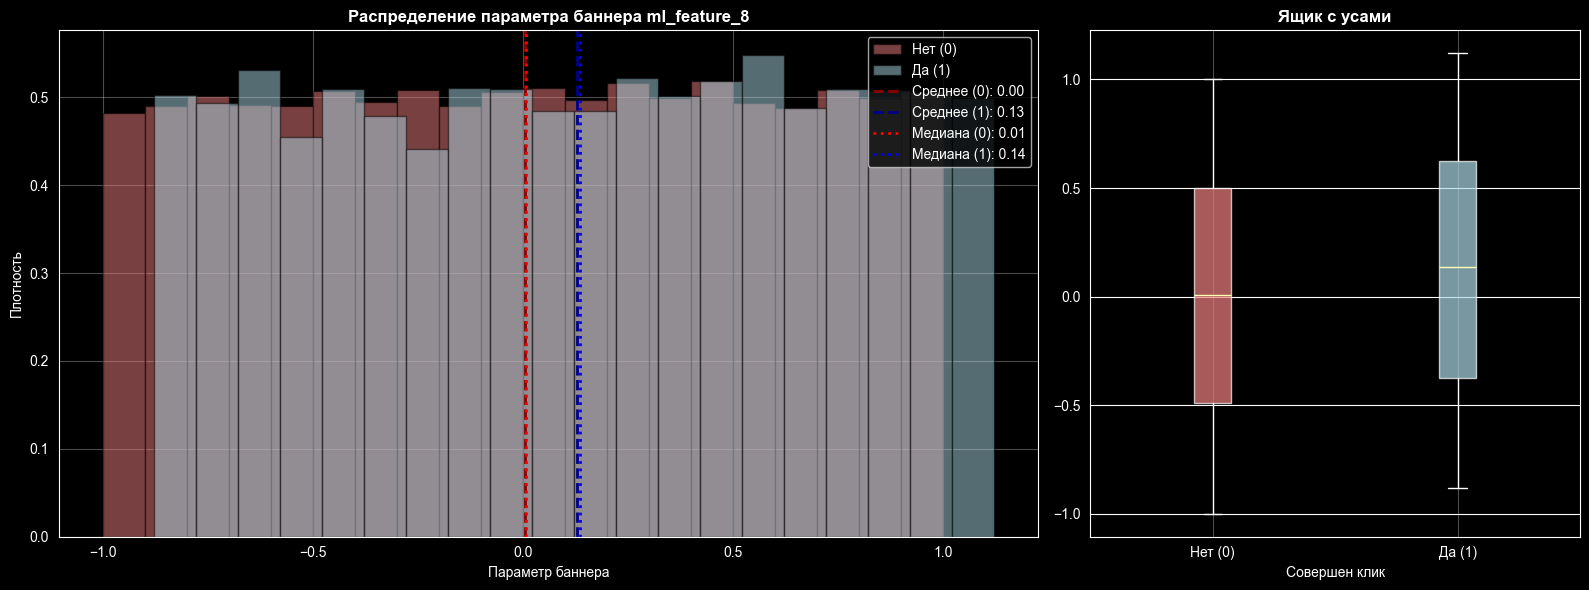

In [149]:
plot_distribution(df, 'click', 'ml_feature_8',
            'Распределение параметра ml_feature_8', 'Параметр баннера', bins=20)

Равномерное распределение. Класс `Да` смещен правее относитнльно 0.

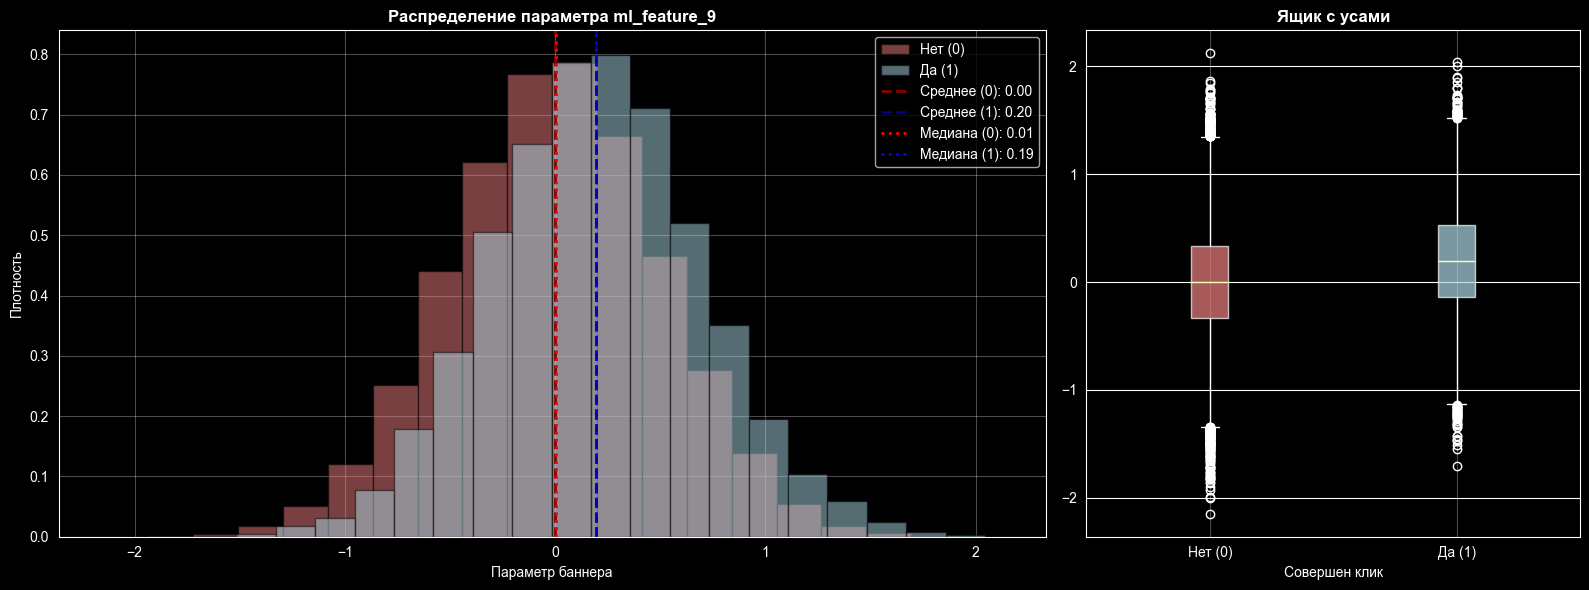

In [150]:
plot_distribution(df, 'click', 'ml_feature_9',
            'Распределение параметра ml_feature_9', 'Параметр баннера', bins=20)

Симметричное распределение для двух классов, но класс `Да` смещен относительно 0 вправо.

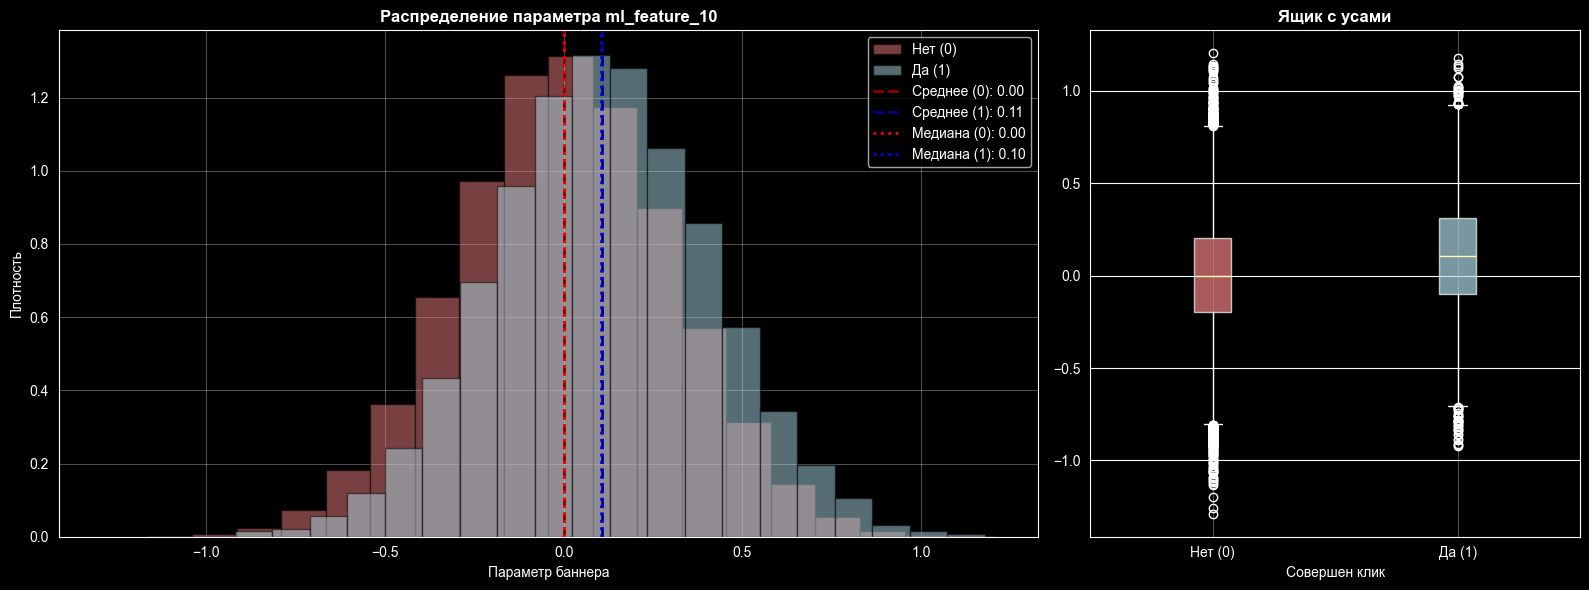

In [151]:
plot_distribution(df, 'click', 'ml_feature_10',
            'Распределение параметра ml_feature_10', 'Параметр баннера', bins=20)

Симметричное распределение для двух классов, но класс `Да` смещен относительно 0 вправо.


#### Оптимизация Датасета

In [157]:
# Класс оптимизации типов данных датафрейма
class DataFrameNormalizer:
    def __init__(self, df):
        self.df = df

    def run(self,
        to_int: list = None,
        to_float: list = None,
        to_category: list = None,
        to_date: list = None
    ) -> pd.DataFrame:
        original_df = self.df.copy()
        if to_int:
            self.to_int(to_int)
        if to_float:
            self.to_float(to_float)
        if to_category:
            self.to_category(to_category)
        if to_date:
            self.to_date(to_date)
        return pd.concat([
            original_df.dtypes.rename('До изменений'),
            self.df.dtypes.rename('После изменений')
        ], axis=1)

    def to_int(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='integer')

    def to_float(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='float')

    def to_category(self, columns: list) -> None:
        for column in columns:
            self.df[column] = df[column].astype('category')

    def to_date(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_datetime(self.df[column], unit='s')

In [169]:
categories = (
    'site_id',
    'site_domain',
    'site_category',
    'app_id',
    'app_domain',
    'app_category',
    'device_model',
    'ml_feature_2',
    'ml_feature_7',
)
int64s = (
    'click',
    'hour',
    'C1',
    'banner_pos',
    'device_type',
    'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'ml_feature_4',

)
float64s = (
    'ml_feature_1',
    'ml_feature_3',
    'ml_feature_5',
    'ml_feature_6',
    'ml_feature_8',
    'ml_feature_9',
    'ml_feature_10',
)
DataFrameNormalizer(df).run(to_int=int64s, to_float=float64s, to_category=categories)

,До изменений,После изменений
click,int8,int8
hour,int32,int32
C1,int16,int16
banner_pos,int8,int8
site_id,category,category
site_domain,category,category
site_category,category,category
app_id,category,category
app_domain,category,category
app_category,category,category


#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.


In [171]:
common_features = [
    'click',
    'hour',
    'site_id',
    'site_domain',
    'site_category',
    'app_id',
    'app_domain',
    'app_category',
    'device_model',
    'device_type',
    'device_conn_type',
]
banner_features = ['banner_pos', 'C1'] + [f'C{feature}' for feature in range(14, 22)]
ml_features = [f'ml_feature_{feature}' for feature in range(1, 11)]

In [176]:
interval_columns = [
    'click', 'hour',   'device_type', 'device_conn_type', 'banner_pos', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'
]
correlation_matrix = phik.phik_matrix(df[common_features + banner_features + ml_features], interval_cols=interval_columns)

interval columns not set, guessing: ['hour', 'device_type', 'device_conn_type', 'banner_pos', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'click']


/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable device_model is large: 2521. Are you sure this is not an interval variable? Analysis for pairs of variables including device_model can be slow.
  warnings.warn(
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable site_id is large: 1160. Are you sure this is not an interval variable? Analysis for pairs of variables including site_id can be slow.
  warnings.warn(
/Users/maksimsesemov/Pycharm

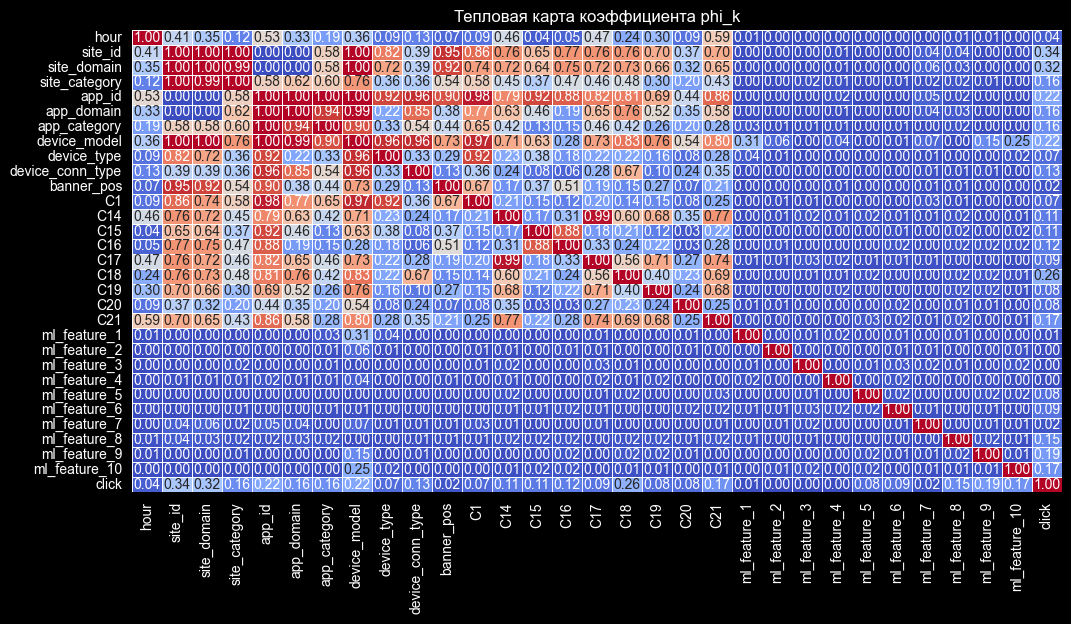

In [177]:
# Строим тепловую карту коэффициента phi_k
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False
           )
plt.title('Тепловая карта коэффициента phi_k')

plt.show()

In [194]:
click_corr = correlation_matrix['click'].drop('click')
threshold = 0.2
low_threshold = 0.01
high_corr_features = click_corr[click_corr > threshold]
zero_corr_features = click_corr[click_corr <= low_threshold]

In [195]:
print(f"Признаки с корреляцией > {threshold}:")
print(high_corr_features.sort_values(ascending=False))
print(f"Признаки с корреляцией <= {low_threshold}:")
print(zero_corr_features.sort_values(ascending=False))

Признаки с корреляцией > 0.2:
site_id         0.336163
site_domain     0.320956
C18             0.257840
app_id          0.221436
device_model    0.219222
Name: click, dtype: float64
Признаки с корреляцией <= 0.01:
ml_feature_2    0.00379
ml_feature_3    0.00000
ml_feature_4    0.00000
Name: click, dtype: float64


Самая высокая корреляция с целевым признаком `click` у `site_id`, `site_domain`, `C18` и `app_id`.
Отсутствует корреляцию у признаков `ml_feature_2`, `ml_feature_3` и `ml_feature_4`, эти признаки можно удалить.

Судя по матрице корреляции и по данным датафрейма, параметры `site_id` и `site_domain` дублируют друг друга и имеют коэффициент корреляции 1. Точно такая же ситуация с параметрами `app_id` и `app_domain`. Параметры `site_domain` и `app_domain` удалим.

In [197]:
df = df.drop(columns=['ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'site_domain', 'app_domain'])

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.